# Hierarchial Audio Classification Using Deep Learning

## Section 0: Imports & Configurations

### Configurations

In [6]:
DATASET = "urbansound8k" # Choose any available dataset from the 'soundata' library
SPECTROGRAM_METHOD = "Mel" # Choose a spectrogram representation: 'STFT', 'Mel', 'MFCCs'

### Import modules

In [5]:
import soundata
import librosa
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
import ast

### Download Dataset
NOTE: If you already have "DATASET" downloaded and verified, you can skip running this section

In [7]:
dataset = soundata.initialize(DATASET)
try:
    print("Validating if Dataset files exists:")
    dataset.validate()
except:
    print("Dataset could not be validated, downloading:")
    dataset.download()  # download the dataset
    dataset.validate()  # validate that all the expected files are there

Validating if Dataset files exists:


100%|██████████| 8732/8732 [00:10<00:00, 816.92it/s]
INFO: Success: the dataset is complete and all files are valid.
INFO: --------------------


## Section 1: Preprocessing of data

### Tagging of Data and Defining class hierarchy

#### Urbansound
Urbansound does not include a hierachical structure, hence we define our own.

In [ ]:
urbansound_id_dict = {0 : "air_conditioner",1 : "car_horn",2 : "children_playing",3 : "dog_bark",4 : "drilling",5 :"engine_idling",6 : "gun_shot",7 : "jackhammer",8 : "siren",9 : "street_music"}


# Define Hierachy structure
hierarchy_US_alt = {
    "human_animal" : [
        {"human": ["children_playing", "street_music"]},
        {"animal": ["dog_bark"]} ],

    "vehicle" : [
        {"vehicle_operation": ["engine_idling"]},
        {"vehicle_signal": ["car_horn", "siren"]}],

    "mechanical": [
        {"construction_tools": ["drilling", "jackhammer"]},
        {"machinery": ["air_conditioner"]}],

    "impact": [
        {"hazardous": ["gun_shot"]}]
    }

hierarchy_US = {
    # NOTE: Taken from taxonomy of urbansound8k
    "human_animal" : [
        {"human": ["children_playing"]},
        {"animal": ["dog_bark"]} ],

    "vehicle" : [
        {"vehicle_operation": ["engine_idling", "car_horn"]},
        {"vehicle_signal": ["siren"]}],

    "mechanical": [
        {"construction": ["drilling", "jackhammer"]},
        {"ventilation": ["air_conditioner"]},
        {"signal": ["gun_shot"]}],
    
    "music": [
        {"recorded": ["street_music"]}]
    }


# Define Class indices for each hierarchy level:
level_class_to_idx_US = {
    0: {
        "human_animal": 0,
        "vehicle": 1,
        "mechanical": 2,
        "music": 3,
    },
    1: {
        "human": 0,
        "animal": 1,
        "vehicle_operation": 2,
        "vehicle_signal": 3,
        "construction": 4,
        "ventilation": 5,
        "signal": 6,
        "recorded": 7,
    },
    2: {
        "air_conditioner": 0,
        "car_horn": 1,
        "children_playing": 2,
        "dog_bark": 3,
        "drilling": 4,
        "engine_idling": 5,
        "gun_shot": 6,
        "jackhammer": 7,
        "siren": 8,
        "street_music": 9,
    }
}


#### Hierarchy label functions

All data will have the hierachical label structure defined as a list: ```hierarchy = [level_1, level_2, ..., level_n]```
- Where the lowest index labels the most coarse level, and the highest index labels the finest level.

In [9]:
def build_label_paths(hierarchy):
    """
    Build mapping: fine_label -> full hierarchy path

    returns: 
        a dictionary with the finest label as the key,
        that points to a list with each index corresponding to the hierarchy label on depth "i"
    """

    label_to_path = {}

    def traverse(node, path):
        if isinstance(node, dict):
            for key, value in node.items():
                traverse(value, path + [key])

        elif isinstance(node, list):
            for item in node:
                traverse(item, path)

        elif isinstance(node, str):
            # leaf node (actual class)
            label_to_path[node] = path + [node]

    traverse(hierarchy, [])
    return label_to_path


def get_max_depth(label_paths):
    return max(len(p) for p in label_paths.values())


def encode_hierarchy(label, label_paths, max_depth):
    """
    Convert label into padded hierarchy levels
    (Automatically pads paths, if the hiearchy does not have equal length along the whole path)
    """
    path = label_paths.get(label, [None])

    # pad to max depth
    padded = path + [None] * (max_depth - len(path))
    return padded

In [10]:
# Choose a hierachy structure
hierarchy = hierarchy_US 

label_paths = build_label_paths(hierarchy) # Returns unpadded label paths -> for fine levels only
max_depth = get_max_depth(label_paths) # Retrieve max depth of the hierarchy (Used for padding)

# Output hierarchy index path for a fine level.
hierarchy_structure = encode_hierarchy(label="dog_bark", label_paths=label_paths, max_depth=max_depth)
print(hierarchy_structure)

['human_animal', 'animal', 'dog_bark']


#### Write Data to CSV
Meta data, will include: Hierachical Label structure 

In [11]:
# Output folder
out_dir = Path("metadata")
out_dir.mkdir(parents=True, exist_ok=True)

def write_csv(output_path, rows):
    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=rows[0].keys())
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved {len(rows)} clips to: {output_path}")

# Save Datasets to CSV
if DATASET == "urbansound8k":
    output_path = out_dir / "urbansound8k_metadata.csv"
    label_paths = build_label_paths(hierarchy_US)
    max_depth = get_max_depth(label_paths)

    rows = []
    for clip_id in dataset.clip_ids:
        clip = dataset.clip(clip_id)

        rows.append({
            "clip_id": clip.clip_id,
            "class_id": clip.class_id,
            "freesound_start_time": clip.freesound_start_time,
            "freesound_end_time": clip.freesound_end_time,
            "salience": clip.salience,
            "slice_file_name": clip.slice_file_name,
            
            "class_label": clip.class_label,
            "hierarchy": encode_hierarchy(label= clip.class_label, label_paths=label_paths, max_depth=max_depth)
        })
    write_csv(output_path, rows)


Saved 8732 clips to: metadata\urbansound8k_metadata.csv


### Data Visualization and Statistics

#### Utility functions for data visualization

In [12]:
def load_with_parsed_hierarchy(csv_path):
    """ 
    Only returns the "hierarchy" column from the meta dataset
    
    """
    df = pd.read_csv(csv_path)
    
    # Convert string → list
    df["hierarchy"] = df["hierarchy"].apply(ast.literal_eval)
    
    return df

def count_by_hierarchy_level(df, level, normalized=False):
    """
    Count occurrences of labels at a given hierarchy level
    
    Args:
        df: pandas DataFrame
        level: int (e.g. 0, 1, 2)
        
    Returns:
        pandas Series (label -> count)
    """
    
    def get_level(h):
        if isinstance(h, list) and len(h) > level:
            return h[level]
        return None

    counts = df["hierarchy"].apply(get_level).value_counts(dropna=True)
    if normalized:
        total = sum(counts)
        counts = counts / total
    
    return counts

def plot_hierarchy_distribution(counts, level, sort=True):
    """
    Plot histogram of hierarchy counts
    
    Args:
        counts: pandas Series from count_by_hierarchy_level
        level: int (for labeling)
        sort: sort bars descending
    """
    
    if sort:
        counts = counts.sort_values(ascending=False)

    plt.figure()
    counts.plot(kind="bar")
    
    plt.title(f"Hierarchy Level {level} Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

def stacked_distribution(df, level_parent, level_child):
    """
    Create a pivot table for stacked plotting
    
    Args:
        df: DataFrame with parsed hierarchy
        level_parent: int (e.g. 0)
        level_child: int (e.g. 1)
        
    Returns:
        pivot table (parent x child counts)
    """

    def get_level(h, level):
        if isinstance(h, list) and len(h) > level:
            return h[level]
        return None

    temp = pd.DataFrame({
        "parent": df["hierarchy"].apply(lambda h: get_level(h, level_parent)),
        "child": df["hierarchy"].apply(lambda h: get_level(h, level_child)),
    })

    pivot = pd.crosstab(temp["parent"], temp["child"])

    return pivot

def plot_stacked_distribution(pivot, normalize=False):
    """
    Plot stacked bar chart
    
    Args:
        pivot: DataFrame from stacked_distribution
        normalize: if True, show proportions instead of counts
    """

    if normalize:
        pivot = pivot.div(pivot.sum(axis=1), axis=0)

    pivot.plot(kind="bar", stacked=True)

    plt.title("Stacked Hierarchy Distribution")
    plt.xlabel("Parent Level")
    plt.ylabel("Proportion" if normalize else "Count")
    plt.xticks(rotation=45, ha="right")

    plt.legend(title="Child Level", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


#### Histograms pr. hierarchy level 

Use the tools to assess the class imbalance

The section below allows for 2D plots:

hierarchy
mechanical      3374
vehicle         2358
human_animal    2000
music           1000
Name: count, dtype: int64


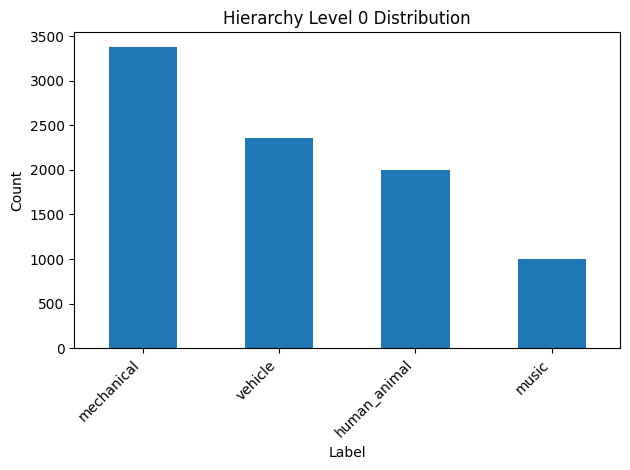

hierarchy
construction         2000
vehicle_operation    1429
human                1000
ventilation          1000
animal               1000
recorded             1000
vehicle_signal        929
signal                374
Name: count, dtype: int64


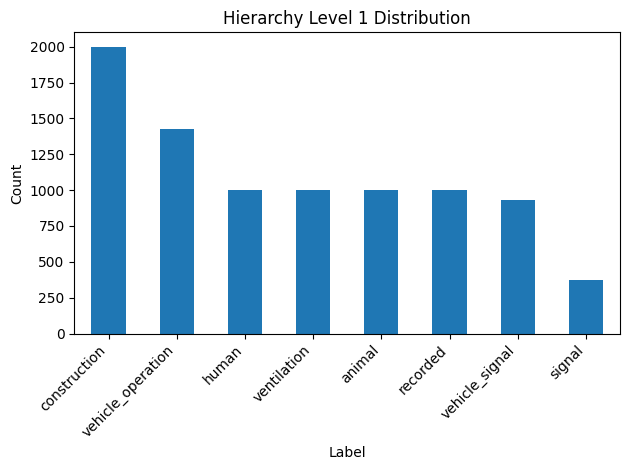

hierarchy
children_playing    1000
air_conditioner     1000
jackhammer          1000
drilling            1000
engine_idling       1000
dog_bark            1000
street_music        1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


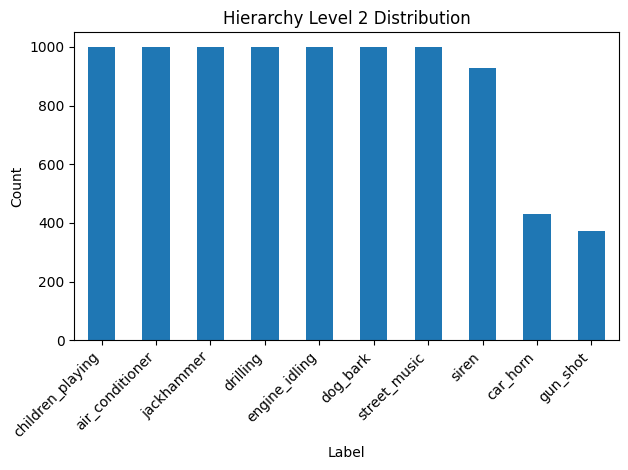

In [13]:
# For URBANSOUND8k
df = load_with_parsed_hierarchy("metadata/urbansound8k_metadata.csv")

# Level 0 (coarse categories)
counts_lvl0 = count_by_hierarchy_level(df, level=0, normalized=False)
print(counts_lvl0)
plot_hierarchy_distribution(counts_lvl0, level=0)

# Level 1 (mid labels)
counts_lvl1 = count_by_hierarchy_level(df, level=1, normalized=False)
print(counts_lvl1)
plot_hierarchy_distribution(counts_lvl1, level=1)

# Level 2 (fine labels)
counts_lvl2 = count_by_hierarchy_level(df, level=2, normalized=False)
print(counts_lvl2)
plot_hierarchy_distribution(counts_lvl2, level=2)

This section below allows for stacked distribution tables:

child         air_conditioner  car_horn  children_playing  dog_bark  drilling  \
parent                                                                          
human_animal                0         0              1000      1000         0   
mechanical               1000         0                 0         0      1000   
music                       0         0                 0         0         0   
vehicle                     0       429                 0         0         0   

child         engine_idling  gun_shot  jackhammer  siren  street_music  
parent                                                                  
human_animal              0         0           0      0             0  
mechanical                0       374        1000      0             0  
music                     0         0           0      0          1000  
vehicle                1000         0           0    929             0  


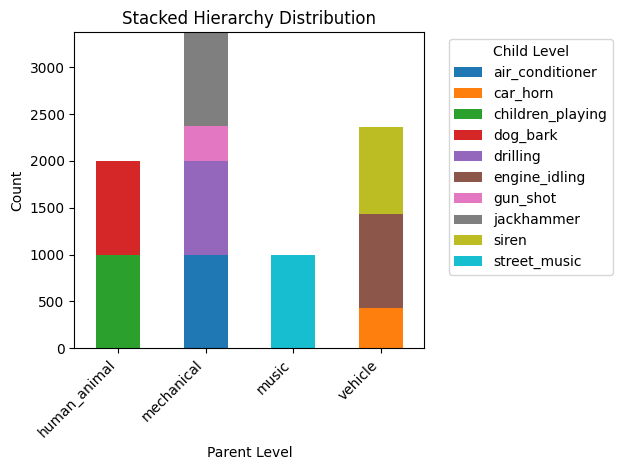

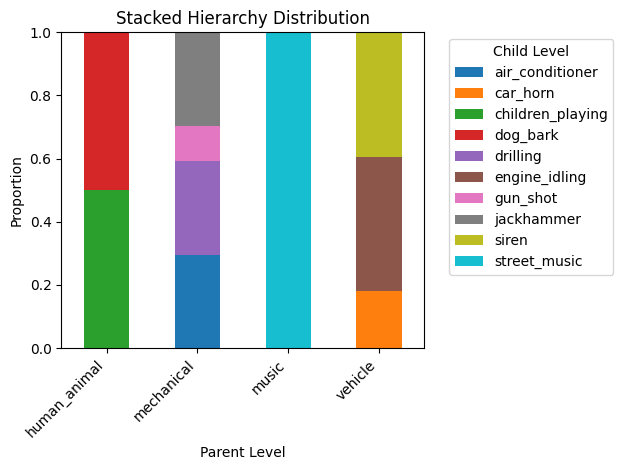

In [14]:
df = load_with_parsed_hierarchy("metadata/urbansound8k_metadata.csv")

# Level 0 → Level 1
pivot = stacked_distribution(df, level_parent=0, level_child=2)

print(pivot)

plot_stacked_distribution(pivot, normalize=False)   # raw counts
plot_stacked_distribution(pivot, normalize=True)    # proportions

Alternatively, you could also make a "Sunburst" plot..

#### Track length inspection

By the inspection of the data the main things we notice is:
- The following classes have most of their clip durations at 4 seconds with a few outliers: air_conditioner, children_playing, engine_idiling, siren, street_music

The main conclusions we can draw by the inspection of the data is:
- Cropping to shortest class is risky, because most classes have long durations
- Short evented clips, like gun_shot and dog_bark, can risk removing the event

The best approach would be:
- Pad all clips to 4 seconds (Preserve information)
- Randomize placement of signal within the padding: [random padding][signal][random padding] (Prevent bias)

What about large outliers, that have very short clip duartions?:
- Outliers are actually real class characteristics
- I don't want to distort the class distribution, remove valid examples and hurt generalization

In [15]:
rows = []

for clip_id in dataset.clip_ids:
    clip = dataset.clip(clip_id)

    audio, sr = clip.audio

    duration = len(audio) / sr

    rows.append({
        "clip_id": clip_id,
        "audio_path": clip.audio_path,
        "class_label": clip.class_label,
        "fold": clip.fold,
        "sr": sr,
        "num_samples": len(audio),
        "duration_sec": duration,
    })

df_lengths = pd.DataFrame(rows)

p:\DataDocuments\DTU\BSc Project\Hierarchical-Audio-Classification-using-Deep-Learning\bsc-hac\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 1000x500 with 0 Axes>

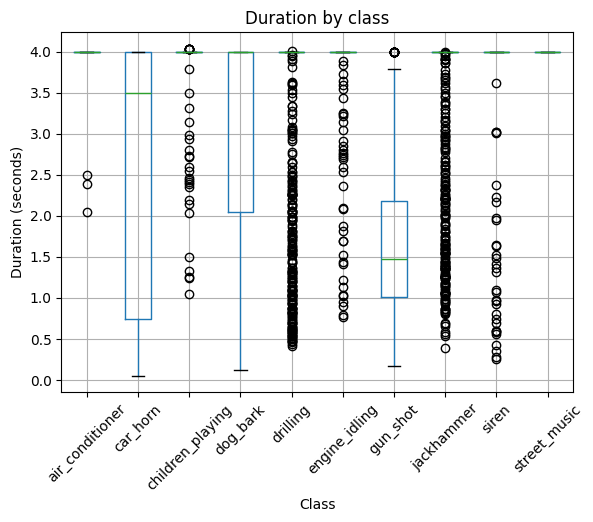

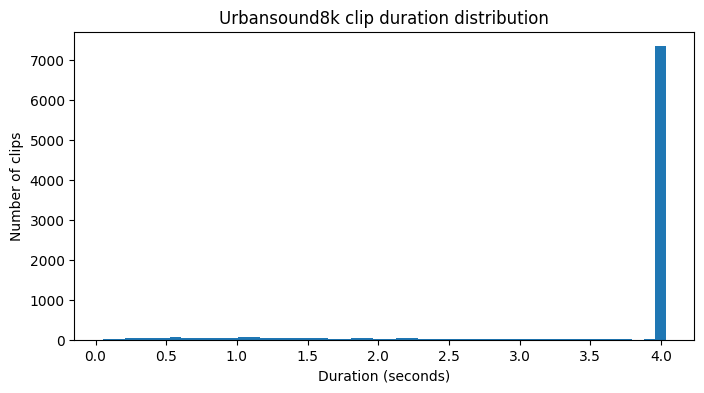

,count,mean,std,min,25%,50%,75%,max
class_label,,,,,,,,
air_conditioner,1000.0,3.994928,0.093128,2.040000,4.000000,4.000000,4.000000,4.000000
car_horn,429.0,2.456125,1.618846,0.050000,0.738299,3.490000,4.000000,4.000000
children_playing,1000.0,3.962095,0.267619,1.048435,4.000000,4.000000,4.000000,4.036667
dog_bark,1000.0,3.148281,1.331572,0.119819,2.040000,4.000000,4.000000,4.000000
drilling,1000.0,3.546295,1.007387,0.416848,4.000000,4.000000,4.000000,4.007937
engine_idling,1000.0,3.935952,0.370908,0.766553,4.000000,4.000000,4.000000,4.000000
gun_shot,374.0,1.647702,0.902516,0.166281,1.009201,1.472698,2.185255,4.000000
jackhammer,1000.0,3.610733,0.885927,0.390000,4.000000,4.000000,4.000000,4.000000
siren,929.0,3.910314,0.502673,0.260000,4.000000,4.000000,4.000000,4.000000


In [16]:
plt.figure(figsize=(10, 5))
df_lengths.boxplot(column="duration_sec", by="class_label", rot=45)
plt.title("Duration by class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Duration (seconds)")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_lengths["duration_sec"], bins=50)
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of clips")
plt.title(F"{DATASET.capitalize()} clip duration distribution")
plt.show()


df_lengths.groupby("class_label")["duration_sec"].describe()

### Signal Processing

#### Theoretic notes (Draft)

In [13]:
"""
Waveform:
|------n_fft------|
[Frame 1]
        |------n_fft------|
        [Frame 2]
                |------n_fft------|
                [Frame 3]

- The width of each window = n_fft

- The step between windows = hop_length

- Due to the Newquist Rate = (f_s / 2), the frequency range of the spectrogram will always be
  constrained to the length of the sample width [0Hz, f_s / 2]. 
  The Nyquist rate sets the maximum frequency you can represent.

"""

'\nWaveform:\n|------n_fft------|\n[Frame 1]\n        |------n_fft------|\n        [Frame 2]\n                |------n_fft------|\n                [Frame 3]\n\n- The width of each window = n_fft\n\n- The step between windows = hop_length\n\n- Due to the Newquist Rate = (f_s / 2), the frequency range of the spectrogram will always be\n  constrained to the length of the sample width [0Hz, f_s / 2]. \n  The Nyquist rate sets the maximum frequency you can represent.\n\n'

#### Utility functions for Audio processing

In [14]:
def extract_features(y, sr, mode="Mel", n_fft=2048, hop_length=512, n_mels=128, n_mfcc=20):
    """
    y       :  audio time-series, np.ndarray [shape=(..., n)]
    sr      :  sampling rate, number > 0 [scalar]
    mode    :  spectrogram representation, [string]

    returns :
      np.ndarray
      - "STFT": dB magnitude spectrogram shape (n_fft/2+1, t)
      - "Mel": dB mel spectrogram shape (128, t)
      - "MFCCs": MFCC matrix shape (20, t)

    NOTE: 
        n_mels or n_mfcc: controls number of mel bands (i.e., frequency bins after mel filterbank).
    """

    if mode == "STFT":
        S = np.abs(librosa.stft(y))
        return librosa.amplitude_to_db(S, n_fft=n_fft, hop_length=hop_length, ref=np.max)

    elif mode == "Mel":
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
        return librosa.power_to_db(S, ref=np.max)

    elif mode == "MFCCs":
        return librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mfcc=n_mfcc)


def plot_spectrogram(S_db, sr, hop_length=512, mode="Mel", cmap="viridis"):
    """
    S_db   : np.ndarray feature matrix in dB (output of extract_features)
    sr     : sample rate
    hop_length: hop length used for STFT/mel (same as used for compute)
    mode   : "STFT" | "Mel" | "MFCCs"
    """
    if mode == "Mel":
        y_axis = "mel"
    elif mode == "STFT":
        y_axis = "linear"
    elif mode == "MFCCs":
        y_axis = "mel"   # any order axis works; MFCC is not freq axis but frame x coef
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    plt.figure(figsize=(8, 4))
    librosa.display.specshow(S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis=y_axis,
        fmin=0,
        fmax= sr / 2, # Nyquist sampling theorem
        cmap=cmap,
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{mode} spectrogram (dB)")
    plt.tight_layout()
    plt.show()

#### (Example) Plotting the spectrogram of Sound Data

In [15]:
example_clip = dataset.choice_clip()  # choose a random example clip
print(example_clip)  # see the available data

Clip(
  audio_path="/tmp\sound_datasets\urbansound8k\audio/fold3/72537-3-0-6.wav",
  clip_id="72537-3-0-6",
  audio: The clip's audio
    * np.ndarray - audio signal
    * float - sample rate,
  class_id: The clip's class id.
    * int - integer representation of the class label (0-9). See Dataset Info in the documentation for mapping,
  class_label: The clip's class label.
    * str - string class name: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, street_music,
  fold: The clip's fold.
    * int - fold number (1-10) to which this clip is allocated. Use these folds for cross validation,
  freesound_end_time: The clip's end time in Freesound.
    * float - end time in seconds of the clip in the original freesound recording,
  freesound_id: The clip's Freesound ID.
    * str - ID of the freesound.org recording from which this clip was taken,
  freesound_start_time: The clip's start time in Freesound.
    * float - start time

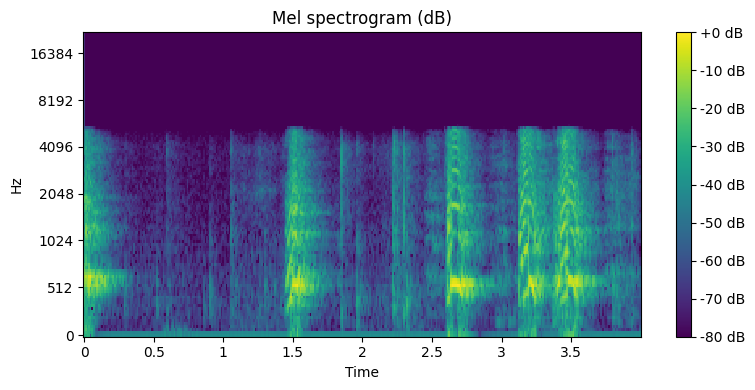

In [16]:
n_fft = 1024
hop_len = 512

# Plot Spectrogram
S_F = extract_features(*example_clip.audio, mode=SPECTROGRAM_METHOD, n_fft=n_fft, hop_length=hop_len)
plot_spectrogram(S_F, example_clip.audio[1], hop_length=hop_len, mode=SPECTROGRAM_METHOD, cmap="viridis")

#### Data Augmentation

In [17]:
# TODO

## Section 2: Model

#### Dataset Adapter

Many datasets are gathered in many different formats, therefore most pipelines can't support to directly process multiple different datasets, straight into it's dataloader. Important data such as, class labels and raw data can be structured differently, depending on how it's imported

Therefore we need a Dataset Adapter layer above the PyTorch dataloader that handles:
- metadata parsing (CSV, hierarchy, labels)
- dataset quirks (UrbanSound vs ESC50 vs custom)
- other dataset specific logic
And finally outputs a clean standardized object, that can be passed straight into the AudioDataset loader.

<span style="color:lightblue; font-weight:bold;">NOTE: </span>It's very important to note that the Dataset Adapter must be outside the model pipeline, as an offline dataset compilation. To reduce complexity, recomputing the dataset format to match the AudioDataset loader everytime the pipeline runs, should be avoided. Therefore, the Data Adapter will work as a light data processing layer on the designated dataset, right before the model pipeline loop.

In [18]:
# We will save a designated dataframe (CSV) coressponding to a distinct dataset in data/.
#  
# Therefore it will only be necessary to run the Data Adapter once pr. dataset and the constructed dataframe
# can just be directly passed straight into the AudioDataset henceforth.

out_dir = Path("data")
out_dir.mkdir(parents=True, exist_ok=True)

# ----------------- Conduct branched flow based on dataset -----------------

if DATASET == "urbansound8k":
    # Load your existing metadata CSV
    meta_path = Path("metadata/urbansound8k_metadata.csv")
    df_meta = pd.read_csv(meta_path)

    rows = []

    for _, row in df_meta.iterrows():

        clip_id = row["clip_id"]

        # Get clip from soundata
        clip = dataset.clip(clip_id)

        # Build audio path
        audio_path = clip.audio_path  # already correct path

        # Parse hierarchy (stored as string in CSV)
        hierarchy = row["hierarchy"]
        if isinstance(hierarchy, str):
            hierarchy = ast.literal_eval(hierarchy)

        rows.append({
            "clip_id": clip_id,
            "audio_path": str(audio_path),
            "class_id": int(row["class_id"]),
            "class_label": row["class_label"],
            "fold": int(clip.fold),
            "hierarchy": hierarchy
        })

    df_out = pd.DataFrame(rows)

    # Save compiled dataset
    output_path = out_dir / "urbansound8k_compiled.csv"
    df_out.to_csv(output_path, index=False)

    print(f"Saved {len(df_out)} samples to: {output_path}")

    



Saved 8732 samples to: data\urbansound8k_compiled.csv


In [19]:
import random
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from pathlib import Path
import soundfile as sf


#### Convolutional Block

A generalized convolutional block class, you can build and apply in various CNN arcitectures.

In [20]:
from model_frameworks.model_utilities import ConvBlock

#### Datawrapper/loader

For audio data, the waveform representations of the audio signals needs to be processed into spectrogram images, in order for the data to be passed as input into the CNN.

In [21]:
from model_frameworks.dataloader_utilities import AudioDataset, AudioTransform

Sanity check the Dataloader and ensure the espected values:

```
(1, mel_bins, time_steps)
tensor(int)
{...}
```

<span style="color:yellow; font-weight:bold;">
WARNING: </span> Please consider using python 3.11, if you want to use torchcodec, else you need to use soundfile


In [22]:
df = pd.read_csv("data/urbansound8k_compiled.csv")

# Check file path validation
if not Path(df.iloc[0]["audio_path"]).exists():
    print("File path for audio data does NOT exist.")
    print("- If running on a new device, try re-running the data adapter...")
else:
    print("File path for audio exists.")

transform = AudioTransform(sample_rate=22050, n_mels=64) # remember to init the log-Mel spectrogram transformer
dataset = AudioDataset(df=df, transform=transform, split="train")
sample = dataset[0]

print("Input shape:", sample["input"].shape)
print("Target:", sample["target"])
print("Index:", sample["index"])
print("Meta:", sample["meta"])

File path for audio exists.
Input shape: torch.Size([1, 64, 442])
Target: tensor(2)
Index: 0
Meta: {'clip_id': '135776-2-0-49', 'label_name': 'children_playing', 'hierarchy': "['human_animal', 'human', 'children_playing']", 'fold': 1}


#### CNN Classes, Loss functions, Metric functions

CNN classes

In [23]:
from model_frameworks.models import VGG16


class TestCNN(nn.Module):
    """ Test CNN for running on Urbansound8k dataset """
    def __init__(self, num_classes=10):
        super().__init__()

        self.blocks = nn.ModuleList([
            ConvBlock(1, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
            ConvBlock(128, 256),
        ])

        self.fc1 = nn.Linear(256, 128)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input: (batch, 1, mel, time)

        for block in self.blocks:
            x = block(x)

        # Global pooling
        x1 = torch.amax(x, dim=[2, 3])
        x2 = torch.mean(x, dim=[2, 3])
        x = x1 + x2

        x = F.relu(self.fc1(x))
        x = self.fc_out(x)

        return x

Loss functions:

In [ ]:
def make_loss_wrapper(criterion):

    def loss_fn(outputs, batch):
        targets = batch["target"]

        # Convert one-hot labels to class indices if needed
        if targets.ndim > 1:
            targets = torch.argmax(targets, dim=1)

        targets = targets.long().to(outputs.device)

        return criterion(outputs, targets)

    return loss_fn


def make_hierarchical_loss_wrapper(criterion:torch.nn, hierarchy_structure:dict, level_weights=None, lambda_h=0.3):
    ce = criterion

    if level_weights is None:
        # example: level_weights = {0: 0.5, 1: 0.7, 2: 1.0} if depth=3, use depth of the hierarchy_structure to assign increasing weights
        # REMOVE: level_weights = {level: (level + 1) / len(hierarchy_structure) for level in range(len(hierarchy_structure))}
    
    def loss_fn(outputs, batch):
        raise NotImplementedError
        # outputs: list[dict] -> [{"level_0": logits_lvl0, level_1": logits_lvl1, ...},... , {"level_0": logits_lvl0, level_1": logits_lvl1, ...}]
        # batch: dict -> {"input": tensor, "target": tensor, "meta": dict, "target_level_0": tensor, "target_level_1": tensor, ...}

        # Extract targets for each level
        # need to extract targets pr level, pr batch
        # target_l0 = batch["target_level_0"].long().to(device)
        # ...
        # target_ln = batch["target_level_n"].long().to(device)

        # Evaluate loss for each level
        # need to extract logits pr level and compare to the corresponding target level, pr batch
        # loss_l0 = ce(outputs[0], target_l0)
        # ...
        # loss_ln = ce(outputs[n], target_ln)

        # Weight each loss according to the level importance and sum them up
        ce_loss = (
            level_weights[0] * loss_l0
            + level_weights[1] * loss_l1
            + level_weights[2] * loss_l2
        )

        # Calculate hierarchy consistency penalty
        # the "hierarchy_structure" should include what the parent-child relationships are, so we can check if the predicted probabilities violate the hierarchy 
        # check if output softmax probabilities violate the defined hierarchy_structure
        # Punish level 2 probability mass assigned to invalid fine classes.
        allowed_01 = hierarchy_info["allowed_01"].to(device)
        allowed_12 = hierarchy_info["allowed_12"].to(device)

        allowed_l1 = p0 @ allowed_01 
        penalty_l1 = (p1 * (1.0 - allowed_l1)).sum(dim=1).mean() 
        allowed_l2 = p1 @ allowed_12 
        penalty_l2 = (p2 * (1.0 - allowed_l2)).sum(dim=1).mean() 
        hierarchy_penalty = penalty_l1 + penalty_l2


        return ce_loss + lambda_h * hierarchy_penalty # scale the hierarchy penalty with lambda_h to control its influence relative to the CE loss


Metric functions

In [25]:
# Quick example metric function:
def accuracy_fn(outputs, batch):
    preds = torch.argmax(outputs, dim=1)
    targets = batch["target"]
    if targets.ndim > 1:
        targets = torch.argmax(targets, dim=1)
    return (preds == targets).float().mean().item()

# TODO: ADD ACCURACY TEST FUNCTION FOR PRINTING PROGRESS

#### Training loop 
- currently is minimal

<span style="color:red; font-weight:bold;">
WARNING: UrbanSound8K is fold-based and needs train on folds 1–9 test on fold 10, with specific data id's already assigned to each fold. If you ignore this, results will be misleading.
</span>


Pre-Loop, define global configurations for the model loop:
- Dataloader (train and test sets)
- Model
- Optimizer
- Criterion (Loss function)
- Optional objects for storing of results

In [ ]:
# ------------ GLOBAL MODEL PARAMETERS ------------
DATASET_PATH = "data/urbansound8k_compiled.csv"

MODEL_CLASS = VGG16   # Set model class (No init)
EPOCHS = 1
LEARNING_RATE = 1e-3    # learning rate
TRAIN_SIZE = 0.8        # Proportion of size of the train_set
TRAIN_BATCH_SIZE = 4    # Batch size: samples pr training iteration
TEST_BATCH_SIZE = 4     # Batch size: samples pr test iteration
NUM_WORKERS = 0
# TODO: Dropout (is in the actual MODEL_CLASS)

SAMPLE_RATE = 22050
N_MELS = 128

SEED = 2131332          # set Seeds for reproducibility
# -------------------------------------------------

dataset_df = pd.read_csv(DATASET_PATH)
print(f"File path for audio exists? = {Path(dataset_df.iloc[0]["audio_path"]).exists()}")
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


# Dataloader:
if DATASET == "urbansound8k":
    # Official UrbanSound8K protocol:
    # fold 10 → test, folds 1–9 → train
    train_data = dataset_df[dataset_df["fold"] != 10].reset_index(drop=True)
    test_data  = dataset_df[dataset_df["fold"] == 10].reset_index(drop=True)

else:
    train_data, test_data = train_test_split(
        dataset_df,
        test_size= 1 - TRAIN_SIZE,
        stratify= dataset_df["class_id"],   # Split the data so that the class proportions are preserved in each split. 
                                            # Requires a list of classes, which indices correspond to the sample in the dataset_df
        random_state= SEED,
    )

print("FULL Dataset: {}".format(dataset_df.shape))  # (nr of samples, columns)
print("TRAIN Dataset: {}".format(train_data.shape)) # (nr of samples, columns)
print("TEST Dataset: {}".format(test_data.shape))   # (nr of samples, columns)

transform = AudioTransform(sample_rate=SAMPLE_RATE, n_mels=N_MELS) # remember to init the log-Mel spectrogram transformer
training_set = AudioDataset(df=train_data, transform=transform, split="train")
testing_set = AudioDataset(df=test_data, transform=transform, split="test")   
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                    'shuffle': True,           # NOTE: 'True' is seen as bad practice, why?
                    'num_workers': NUM_WORKERS
                    }

test_params = {'batch_size': TEST_BATCH_SIZE,
                    'shuffle': False,           # NOTE: 'True' is seen as bad practice, why?
                    'num_workers': NUM_WORKERS
                    }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)


# Model:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 'cuda' if torch.cuda.is_available() else 'cpu'

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model = MODEL_CLASS() # Init model class
model.to(device)


# Criterion
criterion = torch.nn.CrossEntropyLoss() # Pick a nn. critation
which_loss_fn = make_loss_wrapper(criterion)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # TODO: There is other parameters to explore: betas=(0.9, 0.999), eps=1e-08, weight_decay=0., amsgrad=True)


# Logging:
train_losses = []
val_losses = []
val_accuracies = []

File path for audio exists? = True
FULL Dataset: (8732, 6)
TRAIN Dataset: (7895, 6)
TEST Dataset: (837, 6)


p:\DataDocuments\DTU\BSc Project\Hierarchical-Audio-Classification-using-Deep-Learning\bsc-hac\Lib\site-packages\torchaudio\functional\functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


How to inspect a batch:
- See what keys the batch currently has
- Inputs should match your model expectation: (Batch size, 1, mel_bins, time)
- Targets should match model expectation: Class indices -> (classidx_sample_1,..,classidx_sample_n), One-hot -> ([encoding_sample_1], [encoding_sample_2],...,[encoding_sample_n])

In [27]:
demo_training_loader = DataLoader(training_set, **train_params)

batch = next(iter(demo_training_loader)) 
print("Batch Keys:", batch.keys()) # keys for each sample in the batch
inputs = batch["input"]
print("Batch input:",inputs.shape) # Shape informtion of the input
targets = batch["target"]
print("Batch targets:",targets) # List of target, on index corresponding to sample (Will appear random, because of shuffle = True in dataloader params)

Batch Keys: dict_keys(['input', 'target', 'index', 'meta'])
Batch input: torch.Size([4, 1, 128, 442])
Batch targets: tensor([3, 3, 0, 8])


Define architecture of the training and validation loops. These should include:

- Applying bathed samples to both training and validation loops
- Fitting the model using an Epoch loop
- Backpropogating loss through the optimizer using designated loss functions
- Saving of metrics during the respective processes, using designated metric functions

In [28]:
# TRAIN FUNCTION
def train_one_epoch(
    model,                # CNN Class, Other Model Architectures
    dataloader,           # Training loader, (Dataloader object)
    optimizer,            # Optimizatch Adam
    loss_fn,              # Criterion loss function, (Wraps a criterion to pass input and targets from batch)
    device,               # torch.device
    metrics_fn=None,      # 
    augmentation_fn=None  # Augmentation function object, (etc. Mixup, ..)
):
    
    model.train()

    total_loss = 0
    all_metrics = []

    for idx_batch, batch_data in enumerate(dataloader,0):
        # Move to device
        batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch_data.items()}
        # indices = batch.get("index", None) # use for misclassification tracking later

        # Augmentation (Among Batch Data)
        if augmentation_fn is not None:
            batch = augmentation_fn(batch)

        # Forward (Process Batch through the model)
        inputs = batch["input"]
        targets = batch["target"]
        outputs = model(inputs) # Only do model(**batch), if the Model Class can split: batch["input"] -> x, and perhaps augment inside the Model

        # Loss Function (Calculate appropriate loss, weighted by misclassifications & loss_fn)
        loss = loss_fn(outputs, batch) # return batch, to allow the loss_fn to inspect fine_loss = ..., coarse_loss = ... (REQUIRES LOSS_FN WRAPPER)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # TRAIN progress log
        if idx_batch % 20 == 0:
            print(
                f"[TRAIN] Epoch batch {idx_batch}/{len(dataloader)} | "
                f"Loss: {loss.item():.4f}",
                flush=True
            )

        # Metrics (optional)
        if metrics_fn is not None:
            metric = metrics_fn(outputs, batch)
            all_metrics.append(metric)

    avg_loss = total_loss / len(dataloader)
    avg_metric = np.mean(all_metrics) if all_metrics else None

    return {
        "loss": avg_loss,
        "metric": avg_metric
    }


# VALIDATION/TEST FUNCTION
def validate(
    model,              # CNN Class, Other Model Architectures
    dataloader,         # Test/Validation loader, (Dataloader object)
    loss_fn,            # Criterion loss function, (Wraps a criterion to pass input and targets from batch)
    device,             # torch.device
    metrics_fn=None     #
):
    
    model.eval()

    total_loss = 0
    all_metrics = []

    with torch.no_grad():
        for idx_batch, batch_data in enumerate(dataloader,0):
            batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch_data.items()}
            # indices = batch.get("index", None) # use for misclassification tracking later

            inputs = batch["input"]
            # targets = batch["target"]
            outputs = model(inputs) # Only do model(**batch), if the Model Class can split: batch["input"] -> x, and perhaps augment inside the Model

            loss = loss_fn(outputs, batch) # return batch, to allow the loss_fn to inspect fine_loss = ..., coarse_loss = ... (REQUIRES LOSS_FN WRAPPER)
            total_loss += loss.item()

            # VALIDATION progress log
            if idx_batch % 20 == 0:
                print(
                    f"[VAL]   Batch {idx_batch}/{len(dataloader)} | "
                    f"Loss: {loss.item():.4f}",
                    flush=True
                )

            if metrics_fn is not None:
                metric = metrics_fn(outputs, batch)
                all_metrics.append(metric)

    avg_loss = total_loss / len(dataloader)
    avg_metric = np.mean(all_metrics) if all_metrics else None

    return {
        "loss": avg_loss,
        "metric": avg_metric
    }

# EPOCH LOOP (FIT FUNCTION)
def fit(
    model,                  # CNN Class, Other Model Architectures
    train_loader,           # Training loader, (Dataloader object)
    val_loader,             # Test/Validation loader, (Dataloader object)
    optimizer,              # Optimizatch Adam
    loss_fn,                # Criterion loss function, (Wraps a criterion to pass input and targets from batch)
    device,                 # torch.device
    epochs,                 # number of Epochs
    metrics_fn=None,        # 
    augmentation_fn=None,   # Augmentation function object, (etc. Mixup, ..)
    scheduler=None          # Update Learnin Rate at the end of an epoch, (etc. StepLR, ..)
):
    history = {
        # Save metrics and other measurements
        "train_loss": [],
        "val_loss": [],
        "train_metric": [],
        "val_metric": []
    }

    for epoch in range(epochs):
        train_stats = train_one_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device,
            metrics_fn,
            augmentation_fn
        )

        val_stats = validate(
            model,
            val_loader,
            loss_fn,
            device,
            metrics_fn
        )
        # Both loops return "loss" and "metric"

        if scheduler is not None:
            # update the learning rate of the optimizer based on a predefined schedule.
            scheduler.step()

        # Logging
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"[EPOCH {epoch}] Train Loss: {train_stats['loss']:.4f}")
        print(f"[EPOCH {epoch}] Val Loss:   {val_stats['loss']:.4f}")

        if metrics_fn:
            print(f"Train Metric: {train_stats['metric']:.4f}")
            print(f"Val Metric:   {val_stats['metric']:.4f}")

        # Save history
        history["train_loss"].append(train_stats["loss"])
        history["val_loss"].append(val_stats["loss"])
        history["train_metric"].append(train_stats["metric"])
        history["val_metric"].append(val_stats["metric"])

    return history

Initializationg of the Model loop itself, across epochs:

In [29]:
# Final run: init model, optimizer, loss wrapper and call fit()

history = fit(
    model= model,
    train_loader= training_loader,
    val_loader= testing_loader,
    optimizer= optimizer,
    loss_fn= which_loss_fn,
    device= device,
    epochs= EPOCHS,
    metrics_fn= accuracy_fn,
    augmentation_fn= None,
    scheduler= None,
)

# Save model weights and show short summary
Path("models").mkdir(exist_ok=True)
torch.save(model.state_dict(), Path("models") / "final_model.pt")
print("Training finished. History keys:", list(history.keys()))

[TRAIN] Epoch batch 0/1974 | Loss: 2.0744
[TRAIN] Epoch batch 20/1974 | Loss: 2.1411
[TRAIN] Epoch batch 40/1974 | Loss: 2.3808
[TRAIN] Epoch batch 60/1974 | Loss: 3.0887
[TRAIN] Epoch batch 80/1974 | Loss: 2.2138
[TRAIN] Epoch batch 100/1974 | Loss: 2.7275
[TRAIN] Epoch batch 120/1974 | Loss: 2.4744
[TRAIN] Epoch batch 140/1974 | Loss: 2.1660
[TRAIN] Epoch batch 160/1974 | Loss: 2.0556
[TRAIN] Epoch batch 180/1974 | Loss: 2.4970
[TRAIN] Epoch batch 200/1974 | Loss: 2.2327
[TRAIN] Epoch batch 220/1974 | Loss: 2.1294
[TRAIN] Epoch batch 240/1974 | Loss: 2.3322
[TRAIN] Epoch batch 260/1974 | Loss: 1.7933
[TRAIN] Epoch batch 280/1974 | Loss: 1.7691
[TRAIN] Epoch batch 300/1974 | Loss: 1.7980
[TRAIN] Epoch batch 320/1974 | Loss: 2.6565
[TRAIN] Epoch batch 340/1974 | Loss: 1.9879
[TRAIN] Epoch batch 360/1974 | Loss: 3.1672
[TRAIN] Epoch batch 380/1974 | Loss: 2.3015
[TRAIN] Epoch batch 400/1974 | Loss: 2.1558
[TRAIN] Epoch batch 420/1974 | Loss: 2.4654
[TRAIN] Epoch batch 440/1974 | Loss: 2

KeyboardInterrupt: 

In [ ]:
# TODO: MAKE AN ACCURACY TEST AND PRINT IT DURING THE LOGGING